<a href="https://colab.research.google.com/github/A0-J/AI_Security/blob/main/3_Encoder_Decoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3주차 통합 실습: Encoder-Projector-Decoder 구조 분석과 교체 실험

## 주차 목표
VLM을 vision encoder, modality projector, text decoder의 연결 구조로 나누어 이해한다. SmolVLM baseline의 shape 계약을 확인한 뒤, 실제로 encoder와 decoder-side를 바꿔 끼운 VLM에서 caption을 생성해 비교하고, 마지막에 Netron으로 checkpoint의 tensor/module name 구조를 확인한다.

## Section 구성
- **Section 0:** Colab 또는 로컬 실행 환경을 준비하고 GPU 상태를 확인한다.
- **Section 1:** SmolVLM config에서 token geometry와 projector 입출력 차원을 계산한다.
- **Section 2:** encoder 교체와 decoder-side 교체가 어떤 shape 조건에서 실행 가능한지 표로 정리한다.
- **Section 3:** 네 가지 VLM 조합에서 실제 caption을 생성하고 metric을 비교한다.
- **Section 4:** SigLIP과 SigLIP2 image feature의 shape, runtime, 비정렬 cosine 진단값을 확인한다.
- **Section 5:** caption 교체 실험 결과와 encoder 진단 결과를 분리해 저장하고 해석한다.
- **Section 6:** Netron으로 실습 모델 checkpoint의 tensor name, module grouping, weight shape를 확인한다.


## Colab 환경 설정

Colab에서 실행할 때 Google Drive의 프로젝트 경로를 import path에 추가한다. 로컬 실행에서는 다음 셀로 넘어간다.


In [ ]:
# Colab 환경 설정
# 이 셀은 Google Colab에서만 실제 mount를 수행한다.
# 로컬 Jupyter/VS Code에서는 google.colab 모듈이 없으므로 아무 작업 없이 넘어간다.
import importlib.util
import sys

# Drive 안의 저장소 위치다. 본인 Drive 폴더명이 다르면 이 경로만 바꾼다.
DRIVE_PROJECT = '/content/drive/MyDrive/VLM-Lecture2'

# google.colab 모듈 존재 여부로 현재 런타임이 Colab인지 확인한다.
if importlib.util.find_spec('google.colab') is not None:
    from google.colab import drive

    # Drive를 mount해야 notebook에서 저장소 파일과 utils/ 모듈을 읽을 수 있다.
    drive.mount('/content/drive')

    # 저장소 루트를 import path 앞쪽에 넣어 utils.* import가 항상 현재 저장소를 보게 한다.
    if DRIVE_PROJECT not in sys.path:
        sys.path.insert(0, DRIVE_PROJECT)


Mounted at /content/drive


## 로컬 환경 설정

로컬 Jupyter나 VS Code에서 실행할 때 저장소 루트를 찾아 작업 디렉터리와 import path를 맞춘다.


In [ ]:
# 로컬 환경 설정
# 로컬 실행에서는 notebook kernel의 시작 위치가 저장소 루트가 아닐 수 있다.
# index.md가 있는 디렉터리를 저장소 루트로 보고 cwd와 import path를 맞춘다.
import os
import sys
from pathlib import Path

# 현재 디렉터리부터 부모 디렉터리까지 올라가며 저장소 루트를 찾는다.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'index.md').exists():
        LOCAL_PROJECT_PATH = candidate
        break
else:
    # 저장소 루트를 찾지 못한 경우 현재 경로를 그대로 사용한다.
    LOCAL_PROJECT_PATH = Path.cwd()

# 상대 경로 기반 저장/로드가 notebook 실행 위치와 무관하게 동작하도록 cwd를 고정한다.
os.chdir(LOCAL_PROJECT_PATH)
local_project_path = str(LOCAL_PROJECT_PATH)
if local_project_path not in sys.path:
    sys.path.insert(0, local_project_path)
print(f'Local project root: {LOCAL_PROJECT_PATH}')


Local project root: /content


## GPU 확인

현재 런타임의 GPU와 PyTorch CUDA 인식 상태를 확인한다.


In [ ]:
# GPU 확인
# 3주차의 decoder caption 생성과 encoder feature 추출은 GPU 실행을 전제로 한다.
# 먼저 시스템 명령과 PyTorch 양쪽에서 CUDA 상태를 확인한다.
import subprocess

try:
    # nvidia-smi는 GPU 모델명, memory 사용량, driver 상태를 보여준다.
    subprocess.run(['nvidia-smi'], check=False)
except FileNotFoundError:
    print('nvidia-smi 명령을 찾을 수 없습니다. GPU 런타임인지 확인하세요.')

import torch

# PyTorch가 CUDA device를 볼 수 있는지 확인한다.
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


CUDA available: True
GPU: NVIDIA L4


## 필요 라이브러리 설치

Colab에서만 실행한다. PyTorch 계열 package는 Colab 기본 설치를 유지한다.


In [ ]:
# 필요 라이브러리 설치
!pip install -q transformers==4.57.6 datasets==4.8.4 evaluate==0.4.6 huggingface-hub==0.36.2 nltk==3.9.4 pillow==11.3.0 safetensors==0.7.0 tqdm==4.67.3 matplotlib==3.10.8 rich==13.9.4 netron
# Colab 기본 설치 패키지는 보존: torch/torchvision/torchaudio/numpy/pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 137.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 148.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 48.3 MB/s eta 0:00:00


# Section 1. Baseline 구조 점검

SmolVLM-256M-Instruct의 Hugging Face config를 읽고 vision token 수, projected token 수, projector 입출력 차원을 계산한다.


## 공통 import

노트북 전체에서 사용할 표준 라이브러리, Hugging Face class, 저장소 공용 유틸을 불러온다.


In [ ]:
# 공통 import
# 표준 라이브러리: JSON 로드, 경로 처리, 실행 시간 측정, 타입 annotation에 사용한다.
import json
from pathlib import Path
from time import perf_counter
from typing import Any

# 표 형태 비교에는 pandas DataFrame을 사용한다. Colab 기본 package이므로 별도 설치하지 않는다.
import pandas as pd

# torch는 CUDA device, tensor 이동, inference mode, cosine 계산에 사용한다.
import torch
from IPython.display import display

# AutoConfig는 weight 없이 구조만 읽고, AutoModel/AutoProcessor는 encoder 진단에 사용한다.
from transformers import AutoConfig, AutoModel, AutoProcessor

# Caption metric은 notebook 안에서 재구현하지 않고 저장소 공용 util을 재사용한다.
from utils.caption_metrics import compute_caption_metrics

# COCO sample 준비도 공용 dataloader helper를 사용해 다른 주차와 같은 기준을 유지한다.
from utils.coco_dataloader import sample_coco_image_subset

# GPU 선택과 cache 정리는 공용 device util에 맡긴다.
from utils.device_utils import get_device_info, release_cuda_memory, require_cuda_device

# SmolVLM caption 생성, pretrained model loading, generation config 정렬 helper를 재사용한다.
from utils.smolvlm_utils import (
    align_model_generation_config_with_tokenizer,
    ensure_rgb,
    generate_captions,
    load_model_and_processor,
    load_pretrained_model,
)

# 결과 JSON 저장은 directory 생성과 직렬화를 처리하는 공용 helper를 사용한다.
from utils.training_utils import save_json

# Caption metric과 예시 caption 비교는 공용 시각화 helper로 표시한다.
from utils.visualization import show_caption_comparison_cards, show_caption_metric_comparison


## 실행 설정과 상수

이번 노트북에서 실제로 실행할 baseline, decoder-side 비교 모델, encoder 비교 모델, sample 수, 저장 경로를 한곳에 둔다.


In [ ]:
# 실행 설정과 상수
# 이번 실습은 두 SmolVLM checkpoint와 두 SigLIP 계열 encoder만 비교한다.
BASE_MODEL_ID = 'HuggingFaceTB/SmolVLM-256M-Instruct'
DECODER_MODEL_IDS = (
    'HuggingFaceTB/SmolVLM-256M-Instruct',
    'HuggingFaceTB/SmolVLM-500M-Instruct',
)
ENCODER_MODEL_IDS = (
    'google/siglip-base-patch16-512',
    'google/siglip2-base-patch16-512',
)
ENCODER_SWAP_MODEL_ID = 'google/siglip2-base-patch16-512'

# 실제 caption을 생성할 네 가지 조합이다. decoder_side는 projector, text_model, lm_head 묶음을 뜻한다.
SWAP_EXPERIMENT_ROWS = [
    {
        'variant': '256M_full',
        'base_model_id': DECODER_MODEL_IDS[0],
        'encoder_source': DECODER_MODEL_IDS[0],
        'decoder_side_source': DECODER_MODEL_IDS[0],
        'swap_kind': 'full_model',
        'swap_note': '256M full model',
    },
    {
        'variant': '256M_with_siglip2_encoder',
        'base_model_id': DECODER_MODEL_IDS[0],
        'encoder_source': ENCODER_SWAP_MODEL_ID,
        'decoder_side_source': DECODER_MODEL_IDS[0],
        'swap_kind': 'encoder_only',
        'swap_note': '256M decoder-side + SigLIP2 encoder',
    },
    {
        'variant': '500M_decoder_side_with_256M_encoder',
        'base_model_id': DECODER_MODEL_IDS[0],
        'encoder_source': DECODER_MODEL_IDS[0],
        'decoder_side_source': DECODER_MODEL_IDS[1],
        'swap_kind': 'decoder_side',
        'swap_note': '256M encoder + 500M decoder-side',
    },
    {
        'variant': '500M_full',
        'base_model_id': DECODER_MODEL_IDS[1],
        'encoder_source': DECODER_MODEL_IDS[1],
        'decoder_side_source': DECODER_MODEL_IDS[1],
        'swap_kind': 'full_model',
        'swap_note': '500M full model',
    },
]

PROMPT = 'Describe this image in one concise sentence.'
MAX_NEW_TOKENS = 48
SWAP_METRIC_IMAGES = 50
ENCODER_COMPARE_IMAGES = 10
GENERATION_BATCH_SIZE = 2
SEED = 42

STRUCTURE_OUTPUT_DIR = Path('data/3-1-encoder-decoder-structure')
COMPARISON_OUTPUT_DIR = Path('model/3-2-decoder-encoder-comparison')


## Baseline token geometry 계산

Config의 image size, patch size, scale factor, hidden size를 사용해 encoder 출력과 projector 입력/출력 차원을 계산한다.


In [ ]:
# Baseline token geometry 계산
# AutoConfig는 model weight를 받지 않고 config.json만 읽으므로 구조 점검에 적합하다.
base_config = AutoConfig.from_pretrained(BASE_MODEL_ID)
vision_config = base_config.vision_config
text_config = base_config.text_config

# image_size=512, patch_size=16이면 vision encoder는 한 변에 32개 patch를 만든다.
scale_factor = int(getattr(base_config, 'scale_factor', 4))
patches_per_side = int(vision_config.image_size) // int(vision_config.patch_size)
vision_token_count = patches_per_side**2
projected_token_count = vision_token_count // (scale_factor**2)

# structure_report는 Section 2 이후 encoder/decoder-side 비교의 기준 shape 계약이다.
structure_report = {
    'model_id': BASE_MODEL_ID,
    'scale_factor': scale_factor,
    'vision_hidden_size': int(vision_config.hidden_size),
    'vision_image_size': int(vision_config.image_size),
    'vision_patch_size': int(vision_config.patch_size),
    'vision_num_hidden_layers': int(vision_config.num_hidden_layers),
    'text_hidden_size': int(text_config.hidden_size),
    'text_num_hidden_layers': int(text_config.num_hidden_layers),
    'patches_per_side': patches_per_side,
    'vision_token_count': vision_token_count,
    'projected_token_count': projected_token_count,
    'projector_input_dim': int(vision_config.hidden_size) * (scale_factor**2),
    'projector_output_dim': int(text_config.hidden_size),
}

save_json(STRUCTURE_OUTPUT_DIR / 'structure_report.json', structure_report)
structure_table = pd.DataFrame(structure_report.items(), columns=['field', 'value'])
display(structure_table)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

,field,value
0,model_id,HuggingFaceTB/SmolVLM-256M-Instruct
1,scale_factor,4
2,vision_hidden_size,768
3,vision_image_size,512
4,vision_patch_size,16
5,vision_num_hidden_layers,12
6,text_hidden_size,576
7,text_num_hidden_layers,30
8,patches_per_side,32
9,vision_token_count,1024


## scale_factor가 왜 필요한가?

SmolVLM은 vision encoder가 만든 image patch token을 그대로 LLM에 모두 넣지 않는다. Hugging Face 구현에서는 vision encoder output에 `pixel_shuffle(image_hidden_states, self.scale_factor)`를 적용한 뒤, `modality_projection`으로 text embedding space에 투영한다.

흐름은 다음과 같다.

```text
image
→ vision encoder
→ image_hidden_states
→ pixel shuffle로 token 수 감소
→ projector로 text embedding 차원에 맞춤
→ language model 입력
```

SmolVLM 논문에서도 pixel shuffle은 spatial feature를 channel 쪽으로 재배열해 spatial resolution은 낮추고 representational density는 높이며, visual token 수를 줄이는 방법으로 설명된다.

`scale_factor=4`일 때 image sequence length는 다음 공식으로 계산된다.

```text
image_seq_len = ((image_size // patch_size) ** 2) / (scale_factor ** 2)
```

예를 들어 `image_size=512`, `patch_size=16`, `scale_factor=4`이면 vision patch grid는 `512 / 16 = 32`, 즉 `32 × 32 = 1024` tokens이다. Pixel shuffle 이후 token 수는 `1024 / 4^2 = 64` tokens로 줄어든다.

```text
image_features: 1024 visual tokens
→ pixel shuffle
→ 64 visual tokens
```

대신 각 token의 channel dimension은 커진다. 핵심은 공간 token 수를 줄이고, 줄어든 공간 정보를 channel 방향으로 더 조밀하게 담는 것이다.


# Section 2. 비교 variant 구조 확인

실제로 실행할 decoder 두 개와 encoder 두 개만 구조 표에 포함한다. 이 표는 caption 비교와 feature 비교를 해석하기 위한 기준이다.


## Decoder-side variant 구조 확인

SmolVLM-256M과 500M은 각각 완성된 VLM checkpoint다. 순수 text decoder만 교체하면 hidden size가 맞지 않으므로 실행 가능한 교체 단위는 projector, text decoder, lm head를 묶은 decoder-side다. 결과는 표로 비교한다.


In [ ]:
# Decoder-side variant 구조 확인
# 비교할 두 checkpoint의 text decoder config를 읽어 순수 decoder-only 교체와 decoder-side 교체 가능성을 구분한다.
decoder_rows = []
base_text_hidden_size = structure_report['text_hidden_size']
for model_id in DECODER_MODEL_IDS:
    # Config만 읽으므로 아직 model weight는 GPU에 올리지 않는다.
    config = AutoConfig.from_pretrained(model_id)
    text = config.text_config
    text_hidden_size = int(text.hidden_size)
    pure_decoder_status = (
        'baseline_text_hidden_size'
        if model_id == BASE_MODEL_ID
        else f'not_runnable_as_text_decoder_only: {base_text_hidden_size} -> {text_hidden_size}'
    )

    decoder_rows.append(
        {
            'model_id': model_id,
            'text_hidden_size': text_hidden_size,
            'text_layers': int(text.num_hidden_layers),
            'projector_output_dim': text_hidden_size,
            'pure_text_decoder_swap_status': pure_decoder_status,
            # Projector, text_model, lm_head를 함께 교체하면 hidden size 계약이 같이 이동하므로 실행 가능하다.
            'decoder_side_swap_status': 'runnable_as_projector_text_lm_head_bundle',
            'comparison_role': 'baseline_vlm' if model_id == BASE_MODEL_ID else 'larger_decoder_side_vlm',
        }
    )

# caption 교체 실험이 pure decoder-only가 아니라 decoder-side 교체임을 표로 확인한다.
decoder_table = pd.DataFrame(decoder_rows)
display(decoder_table)


config.json: 0.00B [00:00, ?B/s]

,model_id,text_hidden_size,text_layers,projector_output_dim,pure_text_decoder_swap_status,decoder_side_swap_status,comparison_role
0,HuggingFaceTB/SmolVLM-256M-Instruct,576,30,576,baseline_text_hidden_size,runnable_as_projector_text_lm_head_bundle,baseline_vlm
1,HuggingFaceTB/SmolVLM-500M-Instruct,960,32,960,not_runnable_as_text_decoder_only: 576 -> 960,runnable_as_projector_text_lm_head_bundle,larger_decoder_side_vlm


## Encoder variant 구조 확인

SigLIP과 SigLIP2의 hidden size와 image grid가 baseline projector 조건과 어떻게 맞는지 확인한다. Shape가 맞으면 encoder module을 실제 VLM에 연결해 caption 변화를 볼 수 있다. 결과는 표로 비교한다.


In [ ]:
# Encoder variant 구조 확인
# Standalone encoder 후보가 baseline projector shape와 맞는지 config 수준에서 먼저 확인한다.
encoder_rows = []
for model_id in ENCODER_MODEL_IDS:
    # SigLIP 계열 config는 model에 따라 vision_config를 갖거나 config 자체가 vision config일 수 있다.
    config = AutoConfig.from_pretrained(model_id)
    vision = getattr(config, 'vision_config', config)

    # image grid와 patch grid를 읽어 token 수를 계산한다.
    image_size = int(getattr(vision, 'image_size'))
    patch_size = int(getattr(vision, 'patch_size'))
    patches = image_size // patch_size
    tokens = patches**2

    # baseline scale_factor로 나누어떨어질 때만 projected token 수를 계산한다.
    projected_tokens = tokens // (scale_factor**2) if tokens % (scale_factor**2) == 0 else None

    # hidden size와 grid가 baseline과 같아야 기존 projector shape를 그대로 해석할 수 있다.
    same_hidden = int(vision.hidden_size) == structure_report['vision_hidden_size']
    same_grid = (
        image_size == structure_report['vision_image_size']
        and patch_size == structure_report['vision_patch_size']
    )
    shape_compatible = same_hidden and same_grid

    encoder_rows.append(
        {
            'model_id': model_id,
            'hidden_size': int(vision.hidden_size),
            'image_size': image_size,
            'patch_size': patch_size,
            'projected_token_count': projected_tokens,
            'projector_input_match': same_hidden,
            'grid_match': same_grid,
            'shape_compatible': shape_compatible,
            # Shape가 맞더라도 feature 공간 정렬은 별개 문제이므로 실제 caption으로 관찰한다.
            'expected_use': 'runnable_encoder_swap' if shape_compatible else 'requires_projector_adaptation',
        }
    )

# encoder 교체 가능성의 shape 조건을 표로 확인한다.
encoder_table = pd.DataFrame(encoder_rows)
display(encoder_table)


config.json:   0%|          | 0.00/322 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/276 [00:00<?, ?B/s]

,model_id,hidden_size,image_size,patch_size,projected_token_count,projector_input_match,grid_match,shape_compatible,expected_use
0,google/siglip-base-patch16-512,768,512,16,64,True,True,True,runnable_encoder_swap
1,google/siglip2-base-patch16-512,768,512,16,64,True,True,True,runnable_encoder_swap


# Section 3. 실제 Encoder/Decoder-Side 교체 Caption 실험

같은 COCO sample과 같은 prompt로 네 가지 VLM 조합의 caption, metric, 실행 시간을 비교한다. Decoder 교체는 순수 text decoder가 아니라 projector, text decoder, lm head를 함께 쓰는 decoder-side 교체로 정의한다.


## 교체 실험 sample 준비

네 가지 조합이 같은 이미지와 reference caption에서 비교되도록 COCO sample을 고정 seed로 준비한다.


In [ ]:
# 교체 실험 sample 준비
# 실제 caption 생성은 GPU가 필요하므로 여기서 CUDA device를 확정한다.
device = require_cuda_device('cuda')
device_info = get_device_info(str(device))
print('Device:', device_info['device'])
if 'device_name' in device_info:
    print('GPU:', device_info['device_name'])

# 같은 seed와 sample 수를 사용해 네 가지 교체 variant가 같은 이미지에서 비교되도록 한다.
swap_samples = sample_coco_image_subset(
    max_images=SWAP_METRIC_IMAGES,
    seed=SEED,
    show_progress=False,
)

# compute_caption_metrics는 이미지마다 여러 reference caption을 받을 수 있으므로 list[list[str]]로 맞춘다.
reference_captions = [list(sample.get('captions', [sample['caption']])) for sample in swap_samples]
print('Loaded images:', len(swap_samples))


Device: cuda
GPU: NVIDIA L4
11:35:07 |  256 | INFO     | Using saved COCO subset payload: /content/drive/MyDrive/VLM-Lecture2/data/coco_subsets/jxie__coco_captions_train_shuffle_seed42_buffer10000_max50.pkl
Loaded images: 50


## 교체 helper 정의

VLM 안의 vision encoder와 decoder-side module을 실제로 교체한다. Processor는 decoder-side 기준으로 사용한다.


In [ ]:
# 교체 helper 정의
# VLM 내부 module 이름은 Hugging Face Idefics3/SmolVLM 계열 구조를 따른다.
def replace_vision_encoder(target_vlm: Any, encoder_source: Any) -> Any:
    # 완성 VLM은 model.vision_model을, standalone SigLIP 계열은 vision_model을 가진다.
    if hasattr(encoder_source, 'model') and hasattr(encoder_source.model, 'vision_model'):
        vision_model = encoder_source.model.vision_model
    elif hasattr(encoder_source, 'vision_model'):
        vision_model = encoder_source.vision_model
    else:
        vision_model = encoder_source

    # standalone encoder의 config는 encoder_source.config.vision_config 쪽에 있는 경우가 많다.
    source_config = getattr(encoder_source, 'config', None)
    source_vision_config = getattr(source_config, 'vision_config', source_config)
    if source_vision_config is None or not hasattr(source_vision_config, 'patch_size'):
        source_vision_config = getattr(vision_model, 'config', None)
    if source_vision_config is None or not hasattr(source_vision_config, 'patch_size'):
        raise ValueError('교체할 vision encoder config에서 patch_size를 찾지 못했습니다.')

    # 교체 module은 target VLM의 device와 dtype을 따라야 mixed precision linear 연산이 깨지지 않는다.
    target_parameter = next(target_vlm.parameters())
    if hasattr(vision_model, 'to'):
        vision_model = vision_model.to(device=target_parameter.device, dtype=target_parameter.dtype)

    target_vlm.model.vision_model = vision_model
    target_vlm.config.vision_config = source_vision_config
    target_vlm.model.config.vision_config = source_vision_config
    return target_vlm


def replace_decoder_side(target_vlm: Any, decoder_source: Any, processor: Any) -> Any:
    # 256M과 500M은 text hidden size가 다르므로 connector, text_model, lm_head를 함께 교체한다.
    target_vlm.model.connector = decoder_source.model.connector
    target_vlm.model.text_model = decoder_source.model.text_model
    target_vlm.lm_head = decoder_source.lm_head

    # Config도 decoder-side 기준으로 맞춰 generation과 결과 해석이 같은 hidden/vocab 계약을 보게 한다.
    target_vlm.config.text_config = decoder_source.config.text_config
    target_vlm.model.config.text_config = decoder_source.config.text_config
    target_vlm.vocab_size = decoder_source.vocab_size
    target_vlm.model.vocab_size = decoder_source.model.vocab_size
    target_vlm.model.padding_idx = decoder_source.model.padding_idx
    if hasattr(decoder_source, 'generation_config'):
        target_vlm.generation_config = decoder_source.generation_config
    align_model_generation_config_with_tokenizer(target_vlm, processor.tokenizer)
    return target_vlm


## 교체 caption 생성

네 가지 조합을 순서대로 구성해 caption을 생성한다. 한 번에 하나의 조합만 GPU에 올리고 실행 후 memory를 정리한다.


In [ ]:
# 교체 caption 생성
# 각 variant는 필요한 module을 조립한 뒤 같은 sample에서 caption을 만든다.
swap_caption_results = []
for experiment in SWAP_EXPERIMENT_ROWS:
    start_time = perf_counter()
    model = bundle = encoder_source_model = decoder_source_bundle = None

    try:
        bundle = load_model_and_processor(
            model_id=experiment['base_model_id'],
            device=device,
            torch_dtype='auto',
            prefer_flash_attention=True,
        )
        model = bundle['model']
        processor = bundle['processor']
        target_dtype = next(model.parameters()).dtype if device.type == 'cuda' else None

        if experiment['swap_kind'] == 'encoder_only':
            encoder_source_model = load_pretrained_model(
                AutoModel,
                experiment['encoder_source'],
                torch_dtype=target_dtype,
            ).to(device)
            replace_vision_encoder(model, encoder_source_model)
        elif experiment['swap_kind'] == 'decoder_side':
            decoder_source_bundle = load_model_and_processor(
                model_id=experiment['decoder_side_source'],
                device=device,
                torch_dtype='auto',
                prefer_flash_attention=True,
            )
            processor = decoder_source_bundle['processor']
            replace_decoder_side(model, decoder_source_bundle['model'], processor)

        model.eval()
        predictions = generate_captions(
            model=model,
            processor=processor,
            samples=swap_samples,
            device=device,
            prompt=PROMPT,
            max_new_tokens=MAX_NEW_TOKENS,
            batch_size=GENERATION_BATCH_SIZE,
            progress_desc=f"Generating captions: {experiment['variant']}",
        )
        memory_gb = round(sum(p.numel() * p.element_size() for p in model.parameters()) / (1024**3), 3)
    finally:
        if encoder_source_model is not None:
            del encoder_source_model
        if decoder_source_bundle is not None:
            del decoder_source_bundle
        if bundle is not None:
            del bundle
        if model is not None:
            del model
        release_cuda_memory(device)

    swap_caption_results.append(
        {
            'variant': experiment['variant'],
            'encoder_source': experiment['encoder_source'],
            'decoder_side_source': experiment['decoder_side_source'],
            'predictions': predictions,
            'runtime_sec': round(perf_counter() - start_time, 3),
            'parameter_memory_gb': memory_gb,
            'swap_note': experiment['swap_note'],
        }
    )


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Generating captions: 500M_decoder_side_with_256M_encoder:   0%|          | 0/25 [00:00<?, ?it/s]

Generating captions: 500M_full:   0%|          | 0/25 [00:00<?, ?it/s]

## 교체 metric 계산

`swap_caption_results`의 prediction과 reference caption으로 metric을 계산하고, 저장용 row를 만든다. Metric 시각화는 저장된 JSON을 다시 읽는 셀에서 수행한다.


In [ ]:
# 교체 metric 계산
# Prediction과 reference caption으로 metric을 계산해 각 result에 붙인다.
metric_skipped_rows = []

for result in swap_caption_results:
    try:
        result['metrics'] = compute_caption_metrics(result['predictions'], reference_captions)
    except (ImportError, ModuleNotFoundError, RuntimeError) as exc:
        result['metrics'] = {'skipped_reason': f'{type(exc).__name__}: {exc}'}
        metric_skipped_rows.append({'variant': result['variant'], 'reason': result['metrics']['skipped_reason']})

caption_eval_sample_count = len(swap_samples)
print('Caption evaluation samples:', caption_eval_sample_count)

if metric_skipped_rows:
    print('Metric skipped rows:')
    for row in metric_skipped_rows:
        print(f"- {row['variant']}: {row['reason']}")


11:41:29 |  112 | INFO     | TensorFlow version 2.20.0 available.
11:41:29 |  125 | INFO     | JAX version 0.7.2 available.


Caption evaluation samples: 50


## 교체 caption 샘플 확인

예시 이미지는 앞의 2개만 사용한다. 각 이미지는 한 번만 표시하고, 아래에 네 가지 VLM 조합이 만든 caption을 `모델: 캡션` 형식으로 나란히 확인한다.


---
image url(id): 48993


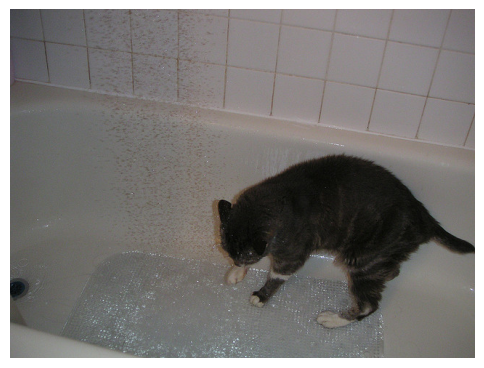

256M_full: In this image we can see a cat in the bathtub.
256M_with_siglip2_encoder: 1]
500M_decoder_side_with_256M_encoder: A Tile Tile Tile Tile Tile Tile Tile Tile Tile Tile Tile Tile Tile Tile Tile Tile Tile Tile Tile Tile Tile Tile Tile T
500M_full: A gray cat is rubbing its face on a plastic dish in the bathtub.
---
image url(id): 120340


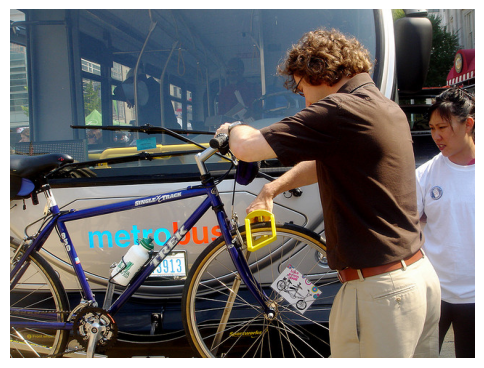

256M_full: In this image we can see a person holding a bicycle and a bicycle is parked on the road. In the background we can see a vehicle, trees, building, and a board.
256M_with_siglip2_encoder: S. (1.s) () () () () () () () () () () () () () () () () () () () () (
500M_decoder_side_with_256M_encoder: This image is a picture of a bicycle. The bicycle is in the center of the image. The bicycle is in white color. The bicycle is in black color. The bicycle is in blue color. The bicycle is in red color. The
500M_full: A man is explaining something to a man who is looking at a bicycle.


In [ ]:
# 교체 caption 샘플 확인
# Metric 숫자만 보지 않고 앞의 두 이미지에서 실제 caption 문장을 같은 이미지 단위로 비교한다.
caption_example_count = 2
caption_prediction_sets = {
    result['variant']: result['predictions']
    for result in swap_caption_results
}

show_caption_comparison_cards(
    swap_samples,
    prediction_sets=caption_prediction_sets,
    max_items=caption_example_count,
    show=True,
)


# Section 4. Encoder feature 진단

같은 이미지 batch를 SigLIP과 SigLIP2 encoder에 통과시켜 feature shape, runtime, memory, 비정렬 cosine 진단값을 비교한다.


## Encoder feature 추출 실행

교체 실험에 쓴 이미지 앞쪽 일부를 재사용해 encoder별 feature를 추출하고 runtime, parameter memory를 기록한다.


In [ ]:
# Encoder feature 추출 실행
# 교체 실험에 쓴 이미지 앞쪽 일부를 재사용해 encoder 진단 축을 맞춘다.
encoder_samples = swap_samples[:ENCODER_COMPARE_IMAGES]
encoder_images = [ensure_rgb(sample['image']) for sample in encoder_samples]
encoder_features = []
encoder_runtime_rows = []

for model_id in ENCODER_MODEL_IDS:
    start_time = perf_counter()
    processor = AutoProcessor.from_pretrained(model_id)
    model = load_pretrained_model(
        AutoModel,
        model_id,
        torch_dtype=torch.float16 if device.type == 'cuda' else None,
    ).to(device)
    model.eval()

    encoded = processor(images=encoder_images, return_tensors='pt')
    encoded = {key: value.to(device) if hasattr(value, 'to') else value for key, value in encoded.items()}

    with torch.inference_mode():
        if hasattr(model, 'get_image_features'):
            features = model.get_image_features(**encoded)
        else:
            outputs = model(**encoded)
            features = outputs.last_hidden_state.mean(dim=1)

    features = torch.nn.functional.normalize(features.float(), dim=-1).cpu()
    encoder_features.append(features)
    encoder_runtime_rows.append(
        {
            'model_id': model_id,
            'feature_dim': int(features.shape[-1]),
            'runtime_sec': round(perf_counter() - start_time, 3),
            'parameter_memory_gb': round(
                sum(parameter.numel() * parameter.element_size() for parameter in model.parameters()) / (1024**3),
                3,
            ),
        }
    )

    del encoded, model
    release_cuda_memory(device)


preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

## Encoder pair 진단 계산

두 encoder의 feature 차원이 같을 때만 비정렬 cosine 진단값을 계산한다. 이 값은 품질 점수가 아니라 feature 분포 관찰용 값이다.


In [ ]:
# Encoder pair 진단 계산
# 두 encoder의 feature 공간은 정렬되어 있지 않으므로 cosine은 품질 점수가 아니라 진단값이다.
encoder_pair_diagnostic = {
    'diagnostic_type': 'unaligned_feature_cosine',
    'model_pair': list(ENCODER_MODEL_IDS),
}

if encoder_features[0].shape[-1] == encoder_features[1].shape[-1]:
    # normalize된 feature끼리 elementwise product를 합하면 sample별 cosine 값이 된다.
    cosine_scores = (encoder_features[0] * encoder_features[1]).sum(dim=-1)
    encoder_pair_diagnostic.update(
        {
            'mean_cosine': round(float(cosine_scores.mean().item()), 6),
            'min_cosine': round(float(cosine_scores.min().item()), 6),
            'max_cosine': round(float(cosine_scores.max().item()), 6),
            'sample_count': int(cosine_scores.shape[0]),
            'metric_status': 'diagnostic_only',
        }
    )
else:
    # feature dimension이 다르면 cosine 자체가 정의되지 않으므로 shape 정보만 남긴다.
    encoder_pair_diagnostic.update(
        {
            'skipped_reason': 'feature dimensions differ',
            'feature_dims': [int(features.shape[-1]) for features in encoder_features],
            'metric_status': 'skipped',
        }
    )


# Section 5. 평가 요약과 저장

Encoder feature 진단 결과를 table로 정리하고, 모델별 caption과 metric만 별도 JSON 파일로 저장한 뒤 다시 읽어 시각화한다.


## 결과 table 생성

Caption 교체 metric은 저장된 JSON을 다시 읽어 표시하고, 여기서는 encoder feature 진단 결과만 별도 table로 정리한다.


In [ ]:
# 결과 table 생성
# Runtime/memory와 pair cosine은 서로 다른 진단이므로 table을 분리해 NaN column을 만들지 않는다.
encoder_runtime_table = pd.DataFrame(
    [
        {
            'variant': row['model_id'].split('/')[-1],
            'feature_dim': row['feature_dim'],
            'runtime_sec': row['runtime_sec'],
            'parameter_memory_gb': row['parameter_memory_gb'],
        }
        for row in encoder_runtime_rows
    ]
)

encoder_pair_table = pd.DataFrame(
    [
        {
            'model_pair': 'SigLIP_to_SigLIP2',
            'diagnostic_type': encoder_pair_diagnostic['diagnostic_type'],
            'mean_cosine': encoder_pair_diagnostic.get('mean_cosine'),
            'min_cosine': encoder_pair_diagnostic.get('min_cosine'),
            'max_cosine': encoder_pair_diagnostic.get('max_cosine'),
            'sample_count': encoder_pair_diagnostic.get('sample_count'),
            'metric_status': encoder_pair_diagnostic.get('metric_status', encoder_pair_diagnostic.get('skipped_reason')),
        }
    ]
)

print('Encoder runtime / memory')
display(encoder_runtime_table)
print('Encoder pair diagnostic')
display(encoder_pair_table)


Encoder runtime / memory


,variant,feature_dim,runtime_sec,parameter_memory_gb
0,siglip-base-patch16-512,768,13.567,0.38
1,siglip2-base-patch16-512,768,11.091,0.70


Encoder pair diagnostic


,model_pair,diagnostic_type,mean_cosine,min_cosine,max_cosine,sample_count,metric_status
0,SigLIP_to_SigLIP2,unaligned_feature_cosine,-0.008615,-0.053146,0.025239,10,diagnostic_only


## Caption/metric JSON 저장

각 모델이 생성한 caption과 metric 결과만 별도 JSON 파일로 Google Drive 경로에 저장한다.


In [ ]:
# Caption/metric JSON 저장
# 모델별 생성 caption과 metric만 Google Drive에 저장한다.
caption_metric_results = [
    {
        'variant': result['variant'],
        'captions': result['predictions'],
        'metrics': result.get('metrics', {}),
    }
    for result in swap_caption_results
]

drive_project_value = globals().get('DRIVE_PROJECT')
drive_project_path = Path(drive_project_value) if drive_project_value else None
caption_metric_output_dir = (
    drive_project_path / COMPARISON_OUTPUT_DIR
    if drive_project_path is not None and drive_project_path.exists()
    else COMPARISON_OUTPUT_DIR
)
caption_metric_json_path = caption_metric_output_dir / 'caption_metric_results.json'
save_json(caption_metric_json_path, caption_metric_results)
print('Saved caption/metric JSON:', caption_metric_json_path)


Saved caption/metric JSON: /content/drive/MyDrive/VLM-Lecture2/model/3-2-decoder-encoder-comparison/caption_metric_results.json


## 저장된 caption/metric JSON 시각화

저장된 JSON 파일을 다시 읽어 metric table과 chart를 확인한다.


Loaded caption/metric JSON: /content/drive/MyDrive/VLM-Lecture2/model/3-2-decoder-encoder-comparison/caption_metric_results.json
Saved variants: 4


                      Saved caption metrics (n=50)                      
                                                                        
  model                                     bleu     meteor    cider_d  
 ────────────────────────────────────────────────────────────────────── 
  256M_full                               0.0134     0.2201     0.0666  
  256M_with_siglip2_encoder               0.0000     0.0303     0.0006  
  500M_decoder_side_with_256M_encoder     0.0122     0.1886     0.1421  
  500M_full                               0.0455     0.3099     0.5198

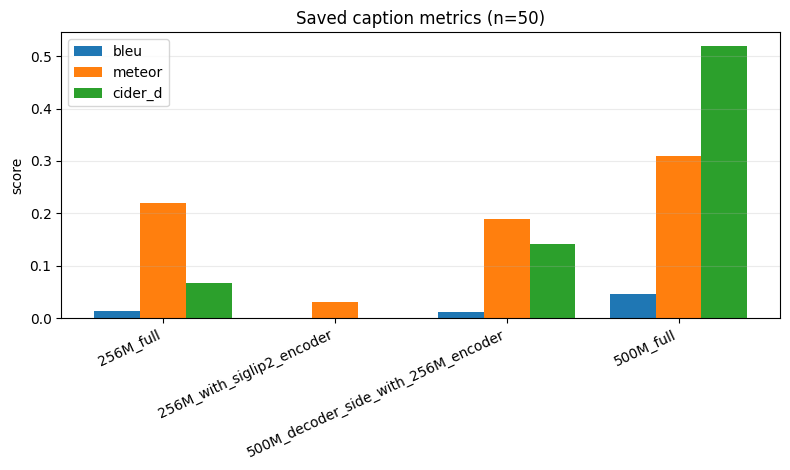

In [ ]:
# 저장된 caption/metric JSON 시각화
# 파일에 저장된 metric만 다시 읽어 rich table과 matplotlib chart로 확인한다.
saved_caption_metric_results = json.loads(caption_metric_json_path.read_text(encoding='utf-8'))
saved_metrics_by_variant = {}
for saved_result in saved_caption_metric_results:
    saved_metrics = saved_result.get('metrics', {})
    if saved_metrics and 'skipped_reason' not in saved_metrics:
        saved_metrics_by_variant[saved_result['variant']] = saved_metrics

print('Loaded caption/metric JSON:', caption_metric_json_path)
print('Saved variants:', len(saved_caption_metric_results))

if saved_metrics_by_variant:
    show_caption_metric_comparison(
        saved_metrics_by_variant,
        title=f'Saved caption metrics (n={caption_eval_sample_count})',
        show_table=True,
        show_chart=True,
    )
else:
    print('No computed metrics found in saved JSON.')


## 실험 결과 해석

이번 교체 실험의 핵심은 **tensor shape가 맞는 것과 VLM이 의미 있게 동작하는 것은 다르다**는 점이다. 네 조합은 모두 실행 가능한 형태로 구성했지만, caption 품질은 encoder, projector, decoder-side가 함께 학습된 조합인지에 따라 크게 갈린다.

| variant | 관찰 결과 | 원인 |
|---|---|---|
| `256M_full` | caption이 정상적으로 생성되지만 표현이 다소 generic하고 반복이 있다. | 256M checkpoint의 encoder, projector, decoder-side가 함께 학습된 정상 조합이다. 모델 크기가 작아 세부 표현력은 제한된다. |
| `256M_with_siglip2_encoder` | `1]`, `() ()` 같은 깨진 문자열이 나오고 metric이 거의 0에 가깝다. | SigLIP2는 hidden size와 image grid는 맞지만, 256M projector가 학습할 때 본 vision feature space와 다르다. projector는 shape만 보는 layer가 아니라 특정 encoder feature 분포를 decoder가 읽을 수 있게 옮기는 adapter다. |
| `500M_decoder_side_with_256M_encoder` | 일부 object는 맞지만 `Tile Tile...`, 색상 나열, 같은 문장 반복이 나타난다. | 500M projector/text decoder/lm head는 500M vision encoder 출력에 맞춰 학습되어 있다. 256M encoder output을 넣으면 projector 입력의 의미 좌표계가 달라져 decoder-side가 불안정하게 반응한다. |
| `500M_full` | 가장 구체적이고 자연스러운 caption을 만들며 BLEU, METEOR, CIDEr-D가 모두 가장 높다. | encoder, projector, decoder-side가 같은 checkpoint 안에서 함께 정렬된 정상 조합이다. |

### Special token 문제가 아닌 이유

깨진 출력은 EOS나 special token 설정이 직접 노출된 결과로 보기 어렵다. Caption 생성 코드는 prompt token을 잘라낸 뒤 `batch_decode(..., skip_special_tokens=True)`로 decoding한다. 또한 model generation config의 `bos_token_id`, `eos_token_id`, `pad_token_id`는 processor tokenizer 기준으로 맞춘다. 같은 generation 경로에서 `500M_full`이 정상 caption을 내므로, tokenizer/EOS 경로 자체는 정상으로 보는 것이 타당하다.

반복 출력은 special token 오류라기보다 **잘못 정렬된 visual condition을 받은 decoder가 높은 확률의 일반 vocab token을 반복해서 선택하는 현상**에 가깝다. 즉 종료 token 설정 문제가 아니라 visual feature와 projector/decoder-side 사이의 alignment가 깨진 것이 주된 원인이다.

### Encoder 진단 결과와의 연결

SigLIP과 SigLIP2는 같은 `hidden_size=768`, `image_size=512`, `patch_size=16` 조건을 만족하므로 shape 수준에서는 교체가 가능하다. 하지만 비정렬 feature cosine 평균이 0에 가깝다는 것은 두 encoder output이 같은 이미지에 대해 같은 방향의 feature 공간을 공유한다고 보기 어렵다는 뜻이다. 이 진단은 `256M_with_siglip2_encoder`의 caption 붕괴를 설명하는 보조 근거가 된다.

### 결론

- 정상 checkpoint 전체를 쓰면 caption이 정상적으로 나온다.
- encoder만 바꾸거나 decoder-side만 바꾸는 조합은 shape-compatible해도 semantic-compatible하지 않을 수 있다.
- projector는 단순한 차원 변환기가 아니라, 특정 vision encoder와 특정 language decoder 사이를 맞추도록 학습된 adapter다.
- 실제로 encoder/decoder-side를 바꿔 쓰려면 projector 재학습 또는 alignment fine-tuning이 필요하다.

따라서 이번 결과는 단순 실패가 아니라, VLM의 encoder, projector, decoder가 독립 부품처럼 보이더라도 실제로는 학습된 결합 관계를 가진다는 점을 보여준다.


# Section 6. Netron으로 checkpoint 구조 확인

Netron으로 3주차에서 사용하는 네 모델의 checkpoint 파일을 열어 tensor name, module grouping, weight shape를 확인한다.

## Netron checkpoint 파일 준비

Hugging Face Hub에서 각 모델 repo의 checkpoint 파일 목록을 읽고, Netron으로 열 대표 파일을 선택한다. 선택 가능한 모델은 표로 확인하고, 실제 checkpoint 다운로드는 다음 viewer 셀에서 선택한 모델 하나에 대해서만 수행한다.


In [ ]:
# Netron checkpoint 파일 준비
# 여기서는 repo 파일 목록만 읽고, 실제 checkpoint 다운로드는 viewer 실행 셀에서 한다.
from huggingface_hub import HfApi, hf_hub_download, hf_hub_url

# Decoder 두 개와 encoder 두 개를 같은 방식으로 다룬다.
netron_model_ids = [*DECODER_MODEL_IDS, *ENCODER_MODEL_IDS]
hf_api = HfApi()
netron_model_rows = []

for row_index, model_id in enumerate(netron_model_ids):
    # repo 파일 목록만 먼저 읽어 가장 적절한 checkpoint 파일을 고른다.
    repo_files = hf_api.list_repo_files(model_id)
    safetensor_files = sorted(
        file_name
        for file_name in repo_files
        if file_name.endswith('.safetensors') and not file_name.endswith('.index.json')
    )

    if 'model.safetensors' in repo_files:
        selected_file = 'model.safetensors'
        netron_note = 'single safetensors checkpoint'
    elif safetensor_files:
        selected_file = safetensor_files[0]
        netron_note = 'representative safetensors shard'
    elif 'pytorch_model.bin' in repo_files:
        selected_file = 'pytorch_model.bin'
        netron_note = 'PyTorch checkpoint fallback'
    else:
        raise FileNotFoundError(f'Netron으로 열 checkpoint 파일을 찾지 못했습니다: {model_id}')

    # sharded checkpoint는 index 파일이 있거나 safetensors shard가 여러 개인 경우로 표시한다.
    is_sharded = any(file_name.endswith('.index.json') for file_name in repo_files) or len(safetensor_files) > 1
    netron_model_rows.append(
        {
            'row_index': row_index,
            'model_id': model_id,
            'selected_file': selected_file,
            'remote_url': hf_hub_url(repo_id=model_id, filename=selected_file),
            'is_sharded': is_sharded,
            'netron_note': netron_note,
            'local_path': None,
        }
    )

# row_index를 보고 다음 셀의 NETRON_TARGET_INDEX 값을 바꿔 원하는 모델을 연다.
netron_table = pd.DataFrame(netron_model_rows)[
    ['row_index', 'model_id', 'selected_file', 'is_sharded', 'netron_note']
]
display(netron_table)


,row_index,model_id,selected_file,is_sharded,netron_note
0,0,HuggingFaceTB/SmolVLM-256M-Instruct,model.safetensors,False,single safetensors checkpoint
1,1,HuggingFaceTB/SmolVLM-500M-Instruct,model.safetensors,False,single safetensors checkpoint
2,2,google/siglip-base-patch16-512,model.safetensors,False,single safetensors checkpoint
3,3,google/siglip2-base-patch16-512,model.safetensors,False,single safetensors checkpoint


## Netron viewer 실행

`NETRON_TARGET_INDEX`를 바꿔 원하는 모델 checkpoint를 연다. Colab에서는 local port proxy 대신 Netron web app의 Hugging Face URL 로딩을 사용하고, 로컬 Jupyter에서는 local Netron server를 사용한다.


In [ ]:
# Netron viewer 실행
# 0: SmolVLM-256M, 1: SmolVLM-500M, 2: SigLIP, 3: SigLIP2
import importlib.util
from urllib.parse import quote
from IPython.display import HTML, IFrame

NETRON_TARGET_INDEX = 0
NETRON_PORT = 8081

selected_netron_row = netron_model_rows[NETRON_TARGET_INDEX]
print('Netron target:', selected_netron_row['model_id'])
print('Checkpoint file:', selected_netron_row['selected_file'])
print('Note:', selected_netron_row['netron_note'])

if importlib.util.find_spec('google.colab') is not None:
    # Colab에서 localhost proxy는 Netron 내부의 /data 요청을 404로 만들 수 있다.
    # Colab에서는 Netron web app이 Hugging Face checkpoint URL을 직접 열도록 한다.
    netron_url = 'https://netron.app/?url=' + quote(selected_netron_row['remote_url'], safe='')
    print('Netron web app URL:', netron_url)
    display(HTML(f'<a href="{netron_url}" target="_blank">Open Netron in a new tab</a>'))
    try:
        display(IFrame(netron_url, width='100%', height=800))
    except Exception as exc:
        print('Netron iframe skipped:', type(exc).__name__, exc)
else:
    # 로컬 Jupyter/VS Code에서는 local server와 localhost iframe을 사용한다.
    import netron

    local_path = hf_hub_download(
        repo_id=selected_netron_row['model_id'],
        filename=selected_netron_row['selected_file'],
    )
    selected_netron_row['local_path'] = local_path
    netron_path = Path(local_path)
    print('Local checkpoint path:', netron_path)

    try:
        netron.stop(('localhost', NETRON_PORT))
    except Exception:
        pass

    address = netron.start(str(netron_path), address=('localhost', NETRON_PORT), browse=False)
    netron_url = f'http://{address[0]}:{address[1]}'
    print('Netron URL:', netron_url)
    try:
        display(netron.widget(address, height=800))
    except Exception as exc:
        print('Netron iframe skipped:', type(exc).__name__, exc)
        print('Open manually:', netron_url)


Netron target: HuggingFaceTB/SmolVLM-256M-Instruct
Checkpoint file: model.safetensors
Note: single safetensors checkpoint
Netron web app URL: https://netron.app/?url=https%3A%2F%2Fhuggingface.co%2FHuggingFaceTB%2FSmolVLM-256M-Instruct%2Fresolve%2Fmain%2Fmodel.safetensors
